## Project Checklist, Theory Foundation, and Online Retail RFM Setup

### What this notebook does

This notebook prepares the **Online Retail** dataset for the full clustering project.

**The raw dataset is transaction-level data. That means one customer can appear in many rows.**

- For clustering, we need customer-level data.

So this notebook converts many transaction rows into one clean customer table.

---

### Main output of this notebook

The most important output is the **RFM customer table**.

| Feature | Meaning | Business use |
|---|---|---|
| **Recency** | Days since the last purchase | Finds recent and inactive customers |
| **Frequency** | Number of invoices/orders | Finds active and one-time customers |
| **Monetary** | Total spend | Finds high-value and low-value customers |

---

### Why this notebook is needed before clustering

Clustering methods need clean features.

Later notebooks will use this prepared data for:

- K-Means,
- MiniBatchKMeans,
- K-Modes,
- K-Medoids,
- K-Prototypes,
- DBSCAN,
- OPTICS,
- DENCLUE-style density demo,
- grid-based clustering demos,
- constraint-based clustering,
- hierarchical clustering,
- BIRCH,
- Gaussian Mixture Models,
- soft clustering,
- and final customer persona analysis.

---

### Files created by this notebook

| File | Used later for |
|---|---|
| `outputs/online_retail_clean.csv` | Reference clean transaction data |
| `outputs/rfm_customer_table.csv` | Main customer table for clustering |
| `outputs/rfm_scaled.csv` | Distance-based clustering |
| `outputs/customer_categorical_features.csv` | K-Modes and K-Prototypes |
| `outputs/rfm_outlier_review.csv` | Outlier-aware clustering decisions |
| `outputs/customer_group_balance_check.csv` | Imbalance and group-size review |
| `outputs/rfm_feature_summary.csv` | Notebook conclusion and documentation |
| `outputs/project_method_checklist.csv` | Project method roadmap |

Only relative folders are used:

- `data/`
- `outputs/`
- `reports/`

No local computer path is shown or stored.

# 1. Project files and learning roadmap

This section lists what we use in the project and where each method will appear.

It is included for one reason:

> We want to make sure no important topic is skipped later.

This is not a modelling step.  
It is the learning roadmap for the full clustering topic.

The project includes:

1. uploaded clustering theory files,
2. the educx Learning Day 8 assignment page,
3. practical Python implementation,
4. business interpretation.

In [1]:
# Create project folders.
# These folders are created in the same project area where this notebook is running.
# We use relative folders only, so the notebook does not show or store your personal computer path.

from pathlib import Path

# DATA_DIR can be used later if we decide to save raw downloaded data.
DATA_DIR = Path("data")

# OUTPUT_DIR stores all cleaned and prepared files used by later notebooks.
OUTPUT_DIR = Path("outputs")

# REPORT_DIR is reserved for future summaries, charts or documentation files.
REPORT_DIR = Path("reports")

# Create the folders if they do not already exist.
for folder in [DATA_DIR, OUTPUT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready:")
print(f"- {DATA_DIR}/")
print(f"- {OUTPUT_DIR}/")
print(f"- {REPORT_DIR}/")

Project folders are ready:
- data/
- outputs/
- reports/


In [2]:
# Project files used.
# This table is a simple learning reference.
# It is not a modelling step.

import pandas as pd

files_used = pd.DataFrame([["educx Learning Day 8 assignment page", "Required checklist: K-Means, DBSCAN, Hierarchical Clustering, Gap Statistic, final metrics table"], ["K-Means / clustering lecture material", "Clustering basics, unsupervised learning, K-Means, K-Medoids, choosing k, clustering families"], ["Density-based clustering / DBSCAN lecture material", "DBSCAN, OPTICS, DENCLUE, density logic, core/border/noise points, grid-based clustering"], ["Practical clustering script and HTML slides", "Python implementation ideas, sklearn API, labels, noise label -1, metrics"], ["Visual clustering notes", "Elbow, linkage, dendrogram, clustering intuition"]], columns=[
    "File or material",
    "How we use it"
])

files_used

,File or material,How we use it
0,educx Learning Day 8 assignment page,"Required checklist: K-Means, DBSCAN, Hierarchi..."
1,K-Means / clustering lecture material,"Clustering basics, unsupervised learning, K-Me..."
2,Density-based clustering / DBSCAN lecture mate...,"DBSCAN, OPTICS, DENCLUE, density logic, core/b..."
3,Practical clustering script and HTML slides,"Python implementation ideas, sklearn API, labe..."
4,Visual clustering notes,"Elbow, linkage, dendrogram, clustering intuition"


In [3]:
# Project method checklist.
# Every method in this list will be used in a practical form later.
# Notebook 1 prepares the data needed for those methods.

project_method_checklist = pd.DataFrame([["Clustering foundation", "Notebook 1", "Explanation with Online Retail examples"], ["Online Retail cleaning", "Notebook 1", "Full implementation"], ["RFM feature engineering", "Notebook 1", "Full implementation"], ["StandardScaler", "Notebook 1", "Full implementation"], ["K-Means", "Notebook 2", "Full Online Retail RFM implementation"], ["MiniBatchKMeans", "Notebook 2", "Practical comparison with K-Means"], ["K-Modes", "Notebook 2", "Categorical customer clustering"], ["K-Medoids", "Notebook 2", "Package-based or simplified medoid implementation"], ["K-Prototypes", "Notebook 2", "Mixed numerical and categorical demo"], ["DBSCAN", "Notebook 3", "Full Online Retail RFM implementation"], ["OPTICS", "Notebook 3", "Package-based implementation"], ["DENCLUE", "Notebook 3", "Simplified density implementation"], ["Grid-based clustering", "Notebook 3", "Grid-cell implementation"], ["STING-style grid statistics", "Notebook 3", "Simplified grid statistics implementation"], ["WaveCluster-style smoothing", "Notebook 3", "Simplified smoothing implementation"], ["CLIQUE-style subspace clustering", "Notebook 3", "Simplified subspace-grid implementation"], ["Constraint-based clustering", "Notebook 3", "Must-link / cannot-link demo"], ["Agglomerative clustering", "Notebook 4", "Full implementation"], ["Single linkage", "Notebook 4", "Practical linkage comparison"], ["Complete linkage", "Notebook 4", "Practical linkage comparison"], ["Average linkage", "Notebook 4", "Practical linkage comparison"], ["Ward linkage and dendrogram", "Notebook 4 and 5", "Full implementation"], ["Divisive clustering", "Notebook 4", "Recursive split demo"], ["BIRCH", "Notebook 4", "Package-based implementation"], ["ROCK-style links", "Notebook 4", "Simplified categorical link demo"], ["CHAMELEON-style graph clustering", "Notebook 4", "Simplified graph demo"], ["Gaussian Mixture Model", "Notebook 4", "Soft clustering implementation"], ["SOM-style customer map", "Notebook 4", "Package or simplified map demo"], ["COBWEB-style hierarchy", "Notebook 4", "Simplified concept hierarchy"], ["Elbow method", "Notebook 2 and 5", "Full implementation"], ["Gap Statistic", "Notebook 4 and 5", "Full implementation"], ["Silhouette Score", "Notebooks 2 to 6", "Full implementation"], ["Davies-Bouldin Index", "Notebooks 4 to 6", "Full implementation"], ["Calinski-Harabasz Score", "Notebooks 4 to 6", "Full implementation"], ["MVD assignment proof", "Notebook 5", "Exact educx checklist proof"], ["Business personas and actions", "Notebook 6", "Final interpretation"]], columns=[
    "Topic",
    "Where it appears",
    "How it is implemented"
])

project_method_checklist.to_csv(OUTPUT_DIR / "project_method_checklist.csv", index=False)

project_method_checklist

,Topic,Where it appears,How it is implemented
0,Clustering foundation,Notebook 1,Explanation with Online Retail examples
1,Online Retail cleaning,Notebook 1,Full implementation
2,RFM feature engineering,Notebook 1,Full implementation
3,StandardScaler,Notebook 1,Full implementation
4,K-Means,Notebook 2,Full Online Retail RFM implementation
5,MiniBatchKMeans,Notebook 2,Practical comparison with K-Means
6,K-Modes,Notebook 2,Categorical customer clustering
7,K-Medoids,Notebook 2,Package-based or simplified medoid implementation
8,K-Prototypes,Notebook 2,Mixed numerical and categorical demo
9,DBSCAN,Notebook 3,Full Online Retail RFM implementation


# 2. Clustering foundation

## What is clustering?

Clustering means finding natural groups in data without labels.

For this project:

- one object = one customer,
- features = customer behaviour values,
- clusters = groups of similar customers.

The algorithm may give labels such as:

- `Cluster 0`
- `Cluster 1`
- `Cluster 2`

These labels are technical labels only.

Our job is to translate them into business meaning, such as:

- loyal high-value customers,
- inactive low-value customers,
- new buyers,
- unusual or outlier customers.

---

## Why Online Retail needs RFM

The raw Online Retail dataset is transaction-level data.

One customer can appear in many rows.

For clustering, we need one row per customer.

So we create:

| Feature | Meaning |
|---|---|
| Recency | How recently the customer bought |
| Frequency | How often the customer bought |
| Monetary | How much the customer spent |

This customer-level table is the base for the next notebooks.

# 3. Environment setup

This notebook is designed for **Python 3.10.9** in VS Code.

The notebook uses:

- pandas
- numpy
- matplotlib
- scikit-learn
- openpyxl
- kagglehub

The next cell installs missing helper packages only if needed.

This is done because the KaggleHub dataset may download as an Excel file, and pandas needs `openpyxl` to read Excel files.

In [4]:
# Import basic Python utilities.
# sys is used to install missing packages into the same Python environment as this notebook.
# subprocess lets us run pip safely from inside the notebook.

import sys
import subprocess
import importlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


def install_if_missing(package_name, import_name=None):
    """Install a package only when it is missing.

    package_name:
        Name used by pip.

    import_name:
        Name used in Python import.
        If not given, it uses package_name.
    """
    import_name = import_name or package_name

    try:
        importlib.import_module(import_name)
        print(f"{import_name} is available.")
    except ImportError:
        print(f"{import_name} is missing. Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        print(f"{package_name} installed.")


# Required for reading Excel files.
install_if_missing("openpyxl", "openpyxl")

# Required for downloading the Kaggle dataset.
# If kagglehub is already working, this will not reinstall it.
install_if_missing("kagglehub[pandas-datasets]", "kagglehub")

openpyxl is available.
kagglehub is available.


In [5]:
# Import project packages.
# These are the main libraries used in this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

Python version: 3.10.9
pandas version: 2.3.3
numpy version: 2.2.6


# 4. Load the Online Retail dataset with KaggleHub

This notebook downloads the dataset directly using KaggleHub.

The loader does four things:

1. downloads the dataset,
2. finds the CSV or Excel file,
3. shows which file was loaded,
4. reads it into pandas.

It does not require manual CSV upload.

In [6]:
# Load Online Retail dataset with KaggleHub.
# This cell uses dataset_download instead of load_dataset.
# dataset_download is more stable because we can directly inspect the downloaded files.

DATASET_NAME = "lakshmi25npathi/online-retail-dataset"


def repair_kagglehub_if_needed():
    """Repair KaggleHub if a package mismatch is detected."""
    print("Repairing KaggleHub package versions...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--no-cache-dir",
        "kagglehub[pandas-datasets]"
    ])

    # Remove partially imported Kaggle modules from memory.
    for module_name in list(sys.modules):
        if module_name.startswith("kagglehub") or module_name.startswith("kagglesdk"):
            del sys.modules[module_name]

    importlib.invalidate_caches()
    print("KaggleHub repair complete.")


def import_kagglehub_safely():
    """Import KaggleHub. If it fails due to version mismatch, repair and retry."""
    try:
        import kagglehub
        print("KaggleHub imported successfully.")
        return kagglehub
    except Exception as first_error:
        print("KaggleHub import failed.")
        print("Reason:", f"{type(first_error).__name__}: {first_error}")

        repair_kagglehub_if_needed()

        try:
            import kagglehub
            print("KaggleHub imported successfully after repair.")
            return kagglehub
        except Exception as second_error:
            raise RuntimeError(
                "KaggleHub still could not be imported after repair. "
                "Restart the VS Code kernel and run the notebook again. "
                f"Final error: {type(second_error).__name__}: {second_error}"
            )


def read_data_file(file_path):
    """Read a CSV or Excel file into pandas."""
    file_path = Path(file_path)

    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path, encoding_errors="ignore")

    if file_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    raise ValueError(f"Unsupported file type: {file_path.suffix}")


def load_online_retail_from_kagglehub():
    """Download Online Retail data and read the most relevant file."""
    kagglehub = import_kagglehub_safely()

    print("Downloading dataset with KaggleHub...")
    dataset_path = Path(kagglehub.dataset_download(DATASET_NAME))

    data_files = []
    data_files += list(dataset_path.rglob("*.csv"))
    data_files += list(dataset_path.rglob("*.xlsx"))
    data_files += list(dataset_path.rglob("*.xls"))

    if not data_files:
        raise FileNotFoundError(
            "KaggleHub downloaded the dataset, but no CSV or Excel file was found."
        )

    # Prefer file names that look relevant.
    preferred_files = [
        file for file in data_files
        if any(word in file.name.lower() for word in ["online", "retail", "ecommerce"])
    ]

    data_file = preferred_files[0] if preferred_files else data_files[0]

    print("Dataset folder:", dataset_path.name)
    print("Reading dataset file:", data_file.name)

    loaded_data = read_data_file(data_file)

    return loaded_data, data_file.name


raw_data, loaded_file_name = load_online_retail_from_kagglehub()

print("Raw data loaded.")
print(f"Loaded file: {loaded_file_name}")
print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]:,}")

raw_data.head()

KaggleHub imported successfully.
Dataset folder: 1
Reading dataset file: online_retail_II.xlsx
Raw data loaded.
Loaded file: online_retail_II.xlsx
Rows: 525,461
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 5. Inspect the loaded file

This cell answers a simple question:

> What file did KaggleHub load, and what columns does it contain?

Different Online Retail files can use different column names.

For example:

| Expected name | Possible dataset name |
|---|---|
| `InvoiceNo` | `Invoice`, `BillNo` |
| `UnitPrice` | `Price`, `Unit Price` |
| `CustomerID` | `Customer ID`, `Customer` |

The next section standardizes these names.

In [7]:
# Inspect the loaded data.
# This helps us verify the exact file structure before cleaning.

print("Loaded file:", loaded_file_name)
print("Dataset shape:", raw_data.shape)

print("\nColumn names:")
for column in raw_data.columns:
    print("-", column)

display(raw_data.head())

Loaded file: online_retail_II.xlsx
Dataset shape: (525461, 8)

Column names:
- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 6. Standardize column names

This section fixes column-name differences.

The rest of the notebook uses these standard names:

| Standard column | Meaning |
|---|---|
| `InvoiceNo` | Invoice/order identifier |
| `StockCode` | Product identifier |
| `Description` | Product description |
| `Quantity` | Quantity purchased |
| `InvoiceDate` | Purchase date |
| `UnitPrice` | Price per unit |
| `CustomerID` | Customer identifier |
| `Country` | Customer country |

If the downloaded file uses names such as `Invoice` or `Price`, they are renamed automatically.

In [38]:
# Create a working copy of the raw data.
# raw_data stays unchanged.
# df is the table we clean and transform.

import re


df = raw_data.copy()


def clean_column_key(column_name):
    """Convert a column name into a simple matching key.

    Example:
    "Customer ID" -> "customerid"
    "Unit Price"  -> "unitprice"
    """
    return re.sub(r"[^a-z0-9]", "", str(column_name).lower())


# Common column-name variants found in Online Retail datasets.
# Left side = cleaned version of possible source column.
# Right side = standard name used in this project.
column_aliases = {
    "invoiceno": "InvoiceNo",
    "invoice": "InvoiceNo",
    "billno": "InvoiceNo",
    "orderno": "InvoiceNo",
    "orderid": "InvoiceNo",

    "stockcode": "StockCode",
    "itemcode": "StockCode",
    "productcode": "StockCode",
    "productid": "StockCode",

    "description": "Description",
    "itemname": "Description",
    "productname": "Description",
    "product": "Description",

    "quantity": "Quantity",
    "qty": "Quantity",

    "invoicedate": "InvoiceDate",
    "date": "InvoiceDate",
    "orderdate": "InvoiceDate",
    "purchasedate": "InvoiceDate",

    "unitprice": "UnitPrice",
    "unitcost": "UnitPrice",
    "price": "UnitPrice",
    "unitpricegbp": "UnitPrice",

    "customerid": "CustomerID",
    "customer": "CustomerID",
    "customerid.": "CustomerID",

    "country": "Country",

    "salesamount": "SalesAmount",
    "amount": "SalesAmount",
    "revenue": "SalesAmount",
    "totalprice": "SalesAmount",
    "totalamount": "SalesAmount",
}

# Build a rename dictionary from the actual dataset columns.
rename_map = {}
for old_column in df.columns:
    column_key = clean_column_key(old_column)
    rename_map[old_column] = column_aliases.get(column_key, old_column)

df = df.rename(columns=rename_map)

# If StockCode is missing but Description exists, use Description as a fallback product identifier.
# This allows us to still calculate UniqueProducts later.
if "StockCode" not in df.columns and "Description" in df.columns:
    df["StockCode"] = df["Description"].astype(str)

# If Description is missing but StockCode exists, use StockCode as a fallback description.
if "Description" not in df.columns and "StockCode" in df.columns:
    df["Description"] = df["StockCode"].astype(str)

# If UnitPrice is missing but SalesAmount and Quantity exist, derive UnitPrice.
# This handles datasets that store total row amount instead of unit price.
if "UnitPrice" not in df.columns and {"SalesAmount", "Quantity"}.issubset(df.columns):
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["SalesAmount"] = pd.to_numeric(df["SalesAmount"], errors="coerce")
    df["UnitPrice"] = df["SalesAmount"] / df["Quantity"].replace(0, np.nan)

# If InvoiceNo is still missing, create a cautious fallback using customer and date.
# This is not ideal, but it is better than stopping the whole project.
# We also print a warning so the limitation is clear.
if "InvoiceNo" not in df.columns and {"CustomerID", "InvoiceDate"}.issubset(df.columns):
    print("Warning: InvoiceNo was not found. Creating fallback InvoiceNo from CustomerID and InvoiceDate.")
    df["InvoiceNo"] = (
        df["CustomerID"].astype(str) + "_" +
        pd.to_datetime(df["InvoiceDate"], errors="coerce").astype(str)
    )

# Final required columns for RFM.
required_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country"
]

missing_columns = [column for column in required_columns if column not in df.columns]

print("Standardized columns:")
for column in df.columns:
    print("-", column)

if missing_columns:
    raise ValueError(
        "The dataset still misses required columns after automatic mapping: "
        f"{missing_columns}. Check the printed column list above."
    )

print("\\nAll required columns are available after mapping.")

Standardized columns:
- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country
\nAll required columns are available after mapping.


# 7. Data type preparation

Before cleaning, we convert key columns into useful data types.

This prevents errors during filtering and RFM calculation.

| Column | Target type |
|---|---|
| `InvoiceNo` | text |
| `InvoiceDate` | datetime |
| `Quantity` | numeric |
| `UnitPrice` | numeric |
| `CustomerID` | text after cleaning |

In [ ]:
# Convert key columns into correct data types.
# This step is needed before cleaning and RFM calculation.
# If these columns stay as wrong data types, filtering and date calculations can fail.

# InvoiceNo is an identifier, not a number for calculation.
# We store it as text so cancelled invoices such as "C489449" can be detected.

df["InvoiceNo"] = df["InvoiceNo"].astype(str)

# InvoiceDate must be a datetime value because Recency uses date differences.
# errors="coerce" converts invalid dates into missing values instead of crashing.

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Quantity and UnitPrice must be numeric because SalesAmount = Quantity × UnitPrice.
# Invalid values become NaN and are handled during cleaning.

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# initial_rows stores the row count before cleaning.
# We use it later in the cleaning funnel and final conclusion.

initial_rows = len(df)

print("Data types prepared.")
print("Rows before cleaning:", f"{initial_rows:,}")

# Preview the key columns after type conversion.
df[["InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice", "CustomerID", "Country"]].head()

Data types prepared.
Rows before cleaning: 525,461


,InvoiceNo,InvoiceDate,Quantity,UnitPrice,CustomerID,Country
0,489434,2009-12-01 07:45:00,12,6.95,13085.0,United Kingdom
1,489434,2009-12-01 07:45:00,12,6.75,13085.0,United Kingdom
2,489434,2009-12-01 07:45:00,12,6.75,13085.0,United Kingdom
3,489434,2009-12-01 07:45:00,48,2.10,13085.0,United Kingdom
4,489434,2009-12-01 07:45:00,24,1.25,13085.0,United Kingdom


# 8. Missing values

Missing values matter because RFM depends on key fields.

The most important field is `CustomerID`.

If `CustomerID` is missing, we cannot assign the purchase to a customer.

In [10]:
# Missing values summary.

missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing Values"})
)

missing_summary["Missing %"] = (missing_summary["Missing Values"] / len(df) * 100).round(2)
missing_summary = missing_summary.sort_values("Missing Values", ascending=False)

missing_summary

,Column,Missing Values,Missing %
6,CustomerID,107927,20.54
2,Description,2928,0.56
1,StockCode,0,0.00
0,InvoiceNo,0,0.00
3,Quantity,0,0.00
4,InvoiceDate,0,0.00
5,UnitPrice,0,0.00
7,Country,0,0.00


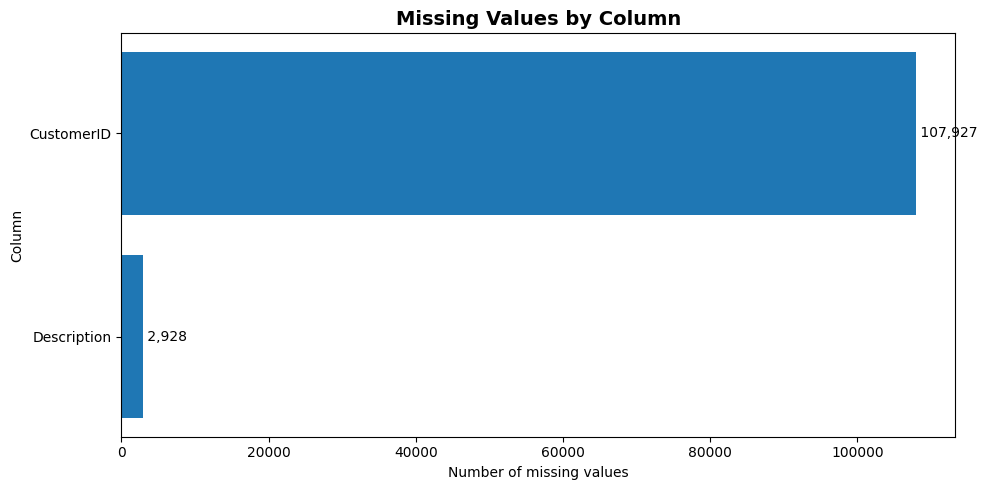

In [ ]:

# Chart 1: Missing values by column.
# Purpose:
# See which columns have missing values before cleaning.

missing_plot_data = missing_summary[missing_summary["Missing Values"] > 0].copy()

if len(missing_plot_data) > 0:
    plt.figure(figsize=(10, 5))
    bars = plt.barh(missing_plot_data["Column"], missing_plot_data["Missing Values"])
    plt.title("Missing Values by Column", fontsize=14, weight="bold")
    plt.xlabel("Number of missing values")
    plt.ylabel("Column")
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height() / 2, f" {int(width):,}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# 9. Data cleaning

We keep valid purchase records only.

Cleaning rules:

| Rule | Reason |
|---|---|
| Remove missing `CustomerID` | We cannot create customer features without a customer ID |
| Remove missing `InvoiceDate` | Recency needs purchase dates |
| Remove cancelled invoices | They are returns or cancellations |
| Keep `Quantity > 0` | Negative or zero quantity is not a normal sale |
| Keep `UnitPrice > 0` | Zero or negative price does not support Monetary |
| Remove duplicate rows | Duplicates can inflate Frequency and Monetary |

We do **not** remove high-value customers just because they are extreme.  
They may be important business customers.

In [12]:
# Create a cleaning summary before filtering.
# This tells us how many rows each issue affects.

cleaning_summary = pd.DataFrame({
    "Check": [
        "Initial rows",
        "Missing CustomerID rows",
        "Missing InvoiceDate rows",
        "Cancelled invoice rows",
        "Quantity <= 0 rows",
        "UnitPrice <= 0 rows",
        "Duplicate rows"
    ],
    "Rows": [
        initial_rows,
        df["CustomerID"].isna().sum(),
        df["InvoiceDate"].isna().sum(),
        df["InvoiceNo"].str.startswith("C", na=False).sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        df.duplicated().sum()
    ]
})

cleaning_summary

,Check,Rows
0,Initial rows,525461
1,Missing CustomerID rows,107927
2,Missing InvoiceDate rows,0
3,Cancelled invoice rows,10206
4,Quantity <= 0 rows,12326
5,UnitPrice <= 0 rows,3690
6,Duplicate rows,6865


In [13]:
# Clean the data step by step.
# The goal is to keep only valid purchase rows.
# We do not remove high-value customers here because they may be important business customers.

# Start from the standardized dataframe.
# clean_data will become the transaction-level table used for RFM creation.
clean_data = df.copy()

# 1. Keep rows with a valid CustomerID and InvoiceDate.
# CustomerID is required because clustering is done at customer level.
# InvoiceDate is required because Recency is based on the last purchase date.

clean_data = clean_data.dropna(subset=["CustomerID", "InvoiceDate"])

# 2. Remove cancelled invoices.
# In Online Retail, cancelled invoices commonly start with "C".
# These are returns/cancellations, not normal purchase behaviour.

clean_data = clean_data[~clean_data["InvoiceNo"].str.startswith("C", na=False)]


# 3. Keep normal purchase rows only.
# Quantity and UnitPrice must both be positive to calculate valid spending.

clean_data = clean_data[(clean_data["Quantity"] > 0) & (clean_data["UnitPrice"] > 0)]

# 4. Remove exact duplicate rows.
# Duplicate rows can inflate Frequency and Monetary values.

clean_data = clean_data.drop_duplicates()

# 5. Create SalesAmount.
# This is the total value of each invoice line.
# It becomes the base for Monetary value.

clean_data["SalesAmount"] = clean_data["Quantity"] * clean_data["UnitPrice"]

# 6. Store CustomerID as clean text.
# CustomerID identifies a customer; it is not used as a mathematical number.

clean_data["CustomerID"] = clean_data["CustomerID"].astype(float).astype(int).astype(str)

print("Rows before cleaning:", f"{initial_rows:,}")
print("Rows after cleaning:", f"{len(clean_data):,}")
print("Rows removed:", f"{initial_rows - len(clean_data):,}")

clean_data.head()

Rows before cleaning: 525,461
Rows after cleaning: 400,916
Rows removed: 124,545


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


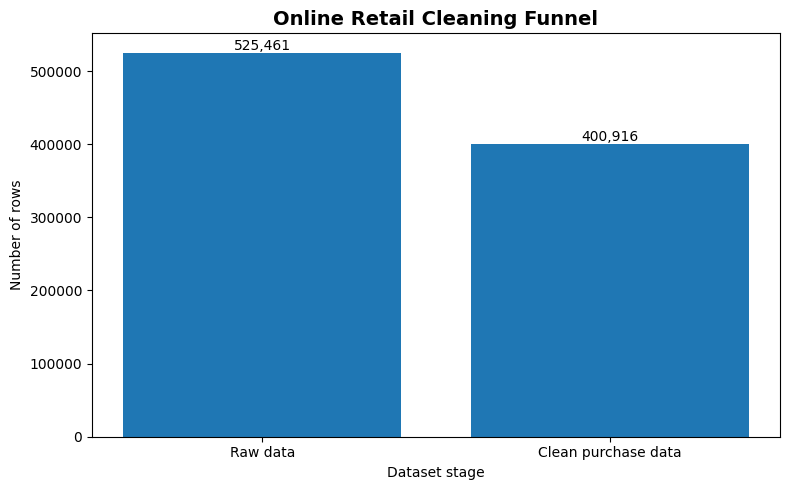

In [14]:
# Chart 2: Cleaning funnel.

# Purpose:
# Show how many rows remain after keeping valid purchase records.

funnel_data = pd.DataFrame({
    "Stage": ["Raw data", "Clean purchase data"],
    "Rows": [initial_rows, len(clean_data)]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(funnel_data["Stage"], funnel_data["Rows"])
plt.title("Online Retail Cleaning Funnel", fontsize=14, weight="bold")
plt.ylabel("Number of rows")
plt.xlabel("Dataset stage")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# 10. RFM feature engineering

Now we convert transaction data into customer-level data.

One row will represent one customer.

Definitions:

| Feature | Calculation |
|---|---|
| Recency | Reference date minus customer's last purchase date |
| Frequency | Number of unique invoices/orders |
| Monetary | Total sales amount |

The reference date is one day after the last invoice date in the dataset.

In [ ]:
# Create the RFM customer table.

# This is the most important output of Notebook 1.
# Each row in rfm represents one customer.

# reference_date is one day after the last purchase date.
# If a customer bought on the final dataset date, their Recency becomes 1 day.

reference_date = clean_data["InvoiceDate"].max() + pd.Timedelta(days=1)


def most_common_clean_product(product_series):
    """Return the most common useful product description for a customer.

    Some Online Retail records contain test-like descriptions.
    We avoid using those as the dominant product label when possible.
    """
    product_text = product_series.dropna().astype(str)

    # Remove obvious test descriptions only for the product label.
    # This does not remove transaction rows from Monetary or Frequency.
    
    product_text = product_text[~product_text.str.lower().str.contains("test product|test", regex=True)]

    if product_text.empty:
        return "Unknown"

    return product_text.mode().iloc[0]


# Group transactions by CustomerID and calculate customer-level behaviour.
rfm = (
    clean_data
    .groupby("CustomerID")
    .agg(
        # Last purchase date is used to calculate Recency.
        LastPurchaseDate=("InvoiceDate", "max"),

        # Recency = how many days since the customer's last purchase.
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),

        # Frequency = how many unique invoices/orders the customer made.
        Frequency=("InvoiceNo", "nunique"),

        # Monetary = total customer spend.
        Monetary=("SalesAmount", "sum"),

        # Extra features for profiling and later interpretation.
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),

        # Country and DominantProduct support categorical methods later.
        Country=("Country", lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown"),
        DominantProduct=("Description", most_common_clean_product)
    )
    .reset_index()
)

# Round Monetary for readable reporting.
rfm["Monetary"] = rfm["Monetary"].round(2)

print("Reference date:", reference_date.date())
print("Customers in RFM table:", f"{rfm.shape[0]:,}")

rfm.head()

Reference date: 2010-12-10
Customers in RFM table: 4,312


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,DominantProduct
0,12346,2010-06-28 13:53:00,165,11,372.86,70,26,United Kingdom,DOORMAT 3 SMILEY CATS
1,12347,2010-12-07 14:57:00,3,2,1323.32,828,70,Iceland,3D DOG PICTURE PLAYING CARDS
2,12348,2010-09-27 14:59:00,74,1,222.16,373,20,Finland,36 DOILIES VINTAGE CHRISTMAS
3,12349,2010-10-28 08:23:00,43,3,2671.14,993,90,Italy,LOVE HEART SOCK HANGER
4,12351,2010-11-29 15:23:00,11,1,300.93,261,21,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP


In [16]:
# RFM summary table.
# This gives the key distribution numbers for Recency, Frequency and Monetary.

rfm_feature_summary = (
    rfm[["Recency", "Frequency", "Monetary", "TotalQuantity", "UniqueProducts"]]
    .describe()
    .T
    .round(2)
)

rfm_feature_summary.to_csv(OUTPUT_DIR / "rfm_feature_summary.csv")

rfm_feature_summary

,count,mean,std,min,25%,50%,75%,max
Recency,4312.0,91.17,96.86,1.00,18.00,53.00,136.00,374.00
Frequency,4312.0,4.46,8.17,1.00,1.00,2.00,5.00,205.00
Monetary,4312.0,2040.41,8911.76,2.95,307.19,701.62,1714.93,349164.35
TotalQuantity,4312.0,1280.05,6457.93,1.00,156.00,380.00,992.00,220600.00
UniqueProducts,4312.0,63.65,85.76,1.00,17.00,38.00,79.25,1741.00


# 11. Categorical customer features for later notebooks

K-Modes and K-Prototypes need categorical features.

So we prepare a customer-level categorical table now.

We create:

| Feature | Purpose |
|---|---|
| `Country` | Dominant customer country |
| `DominantProduct` | Most common product description for the customer |
| `RecencyGroup` | Recent / Warm / Inactive |
| `FrequencyGroup` | Low / Medium / High |
| `MonetaryGroup` | Low / Medium / High |

These features will be used later for K-Modes and K-Prototypes.

In [17]:
# Create simple categorical groups from RFM values.
# These bins help K-Modes work with customer behaviour categories.

customer_categories = rfm[[
    "CustomerID", "Country", "DominantProduct",
    "Recency", "Frequency", "Monetary"
]].copy()

# Recency:
# lower values are better, so the labels are ordered from Recent to Inactive.
customer_categories["RecencyGroup"] = pd.qcut(
    customer_categories["Recency"].rank(method="first"),
    q=3,
    labels=["Recent", "Warm", "Inactive"]
)

# Frequency:
# higher values are better.
customer_categories["FrequencyGroup"] = pd.qcut(
    customer_categories["Frequency"].rank(method="first"),
    q=3,
    labels=["Low Frequency", "Medium Frequency", "High Frequency"]
)

# Monetary:
# higher values are better.
customer_categories["MonetaryGroup"] = pd.qcut(
    customer_categories["Monetary"].rank(method="first"),
    q=3,
    labels=["Low Monetary", "Medium Monetary", "High Monetary"]
)

# Keep only categorical fields for the later K-Modes notebook.
customer_categorical_features = customer_categories[[
    "CustomerID", "Country", "DominantProduct",
    "RecencyGroup", "FrequencyGroup", "MonetaryGroup"
]].copy()

customer_categorical_features.head()

,CustomerID,Country,DominantProduct,RecencyGroup,FrequencyGroup,MonetaryGroup
0,12346,United Kingdom,DOORMAT 3 SMILEY CATS,Inactive,High Frequency,Low Monetary
1,12347,Iceland,3D DOG PICTURE PLAYING CARDS,Recent,Low Frequency,High Monetary
2,12348,Finland,36 DOILIES VINTAGE CHRISTMAS,Warm,Low Frequency,Low Monetary
3,12349,Italy,LOVE HEART SOCK HANGER,Warm,Medium Frequency,High Monetary
4,12351,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP,Recent,Low Frequency,Low Monetary


# 12. RFM exploratory analysis

The charts below are focused and non-repetitive.

Each chart has a clear purpose:

1. Recency distribution shows how recently customers purchased.
2. Frequency distribution shows how often customers purchased.
3. Monetary distribution shows customer value spread.
4. Frequency vs Monetary gives a first customer segmentation view.
5. Country distribution supports later K-Modes and K-Prototypes.

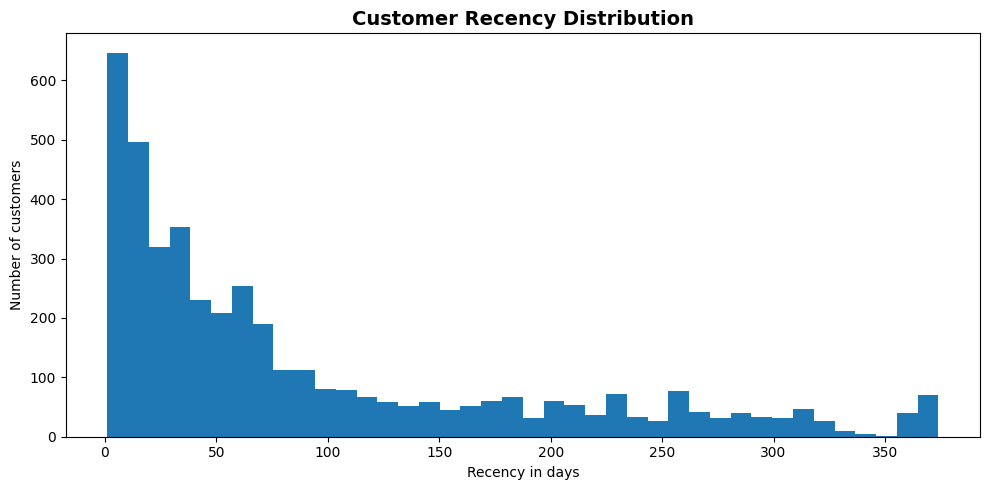

In [18]:
# Chart 3: Recency distribution.
# Purpose:
# Understand how many customers purchased recently vs long ago.

plt.figure(figsize=(10, 5))
plt.hist(rfm["Recency"], bins=40)
plt.title("Customer Recency Distribution", fontsize=14, weight="bold")
plt.xlabel("Recency in days")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

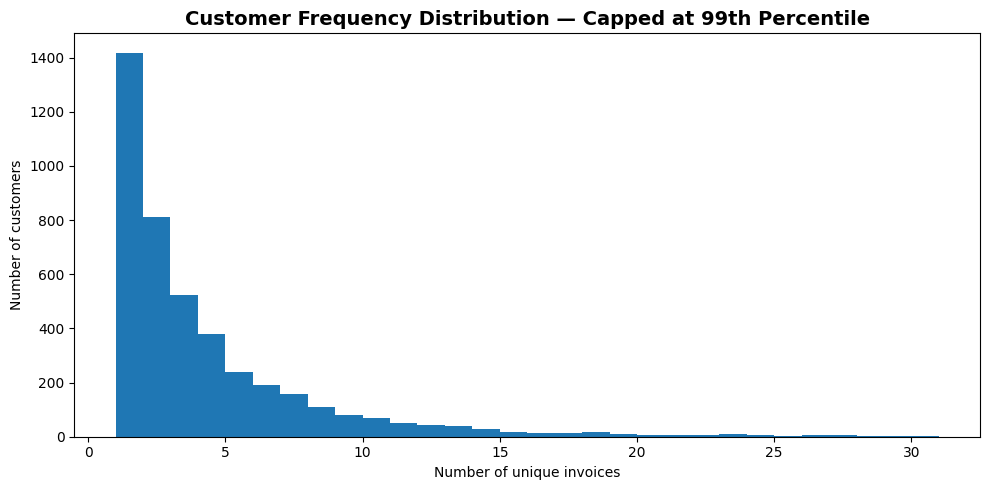

In [19]:
# Chart 4: Frequency distribution with capped view.
# Purpose:
# Show the typical purchase frequency without a few extreme customers dominating the chart.

frequency_cap = rfm["Frequency"].quantile(0.99)
frequency_plot = rfm[rfm["Frequency"] <= frequency_cap]

plt.figure(figsize=(10, 5))
plt.hist(frequency_plot["Frequency"], bins=30)
plt.title("Customer Frequency Distribution — Capped at 99th Percentile", fontsize=14, weight="bold")
plt.xlabel("Number of unique invoices")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

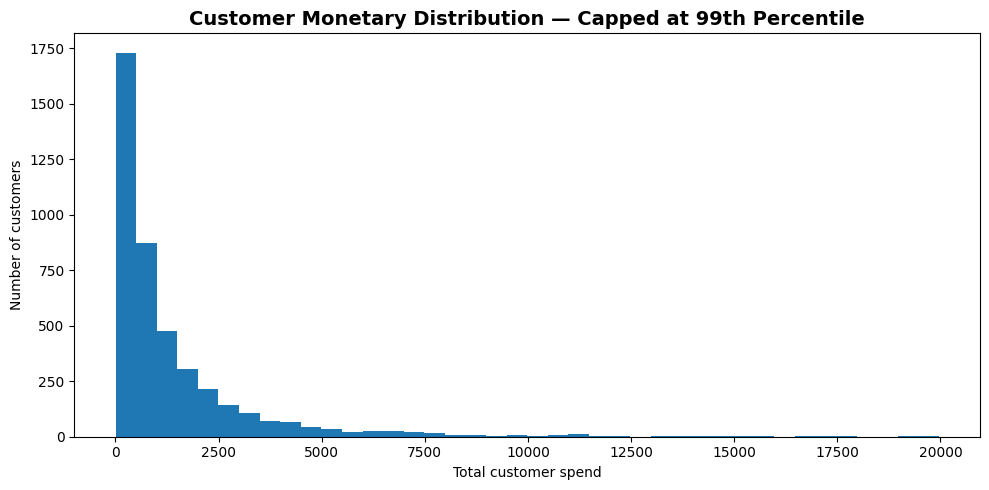

In [20]:
# Chart 5: Monetary distribution with capped view.
# Purpose:
# Show the usual customer spend range while keeping the chart readable.

monetary_cap = rfm["Monetary"].quantile(0.99)
monetary_plot = rfm[rfm["Monetary"] <= monetary_cap]

plt.figure(figsize=(10, 5))
plt.hist(monetary_plot["Monetary"], bins=40)
plt.title("Customer Monetary Distribution — Capped at 99th Percentile", fontsize=14, weight="bold")
plt.xlabel("Total customer spend")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

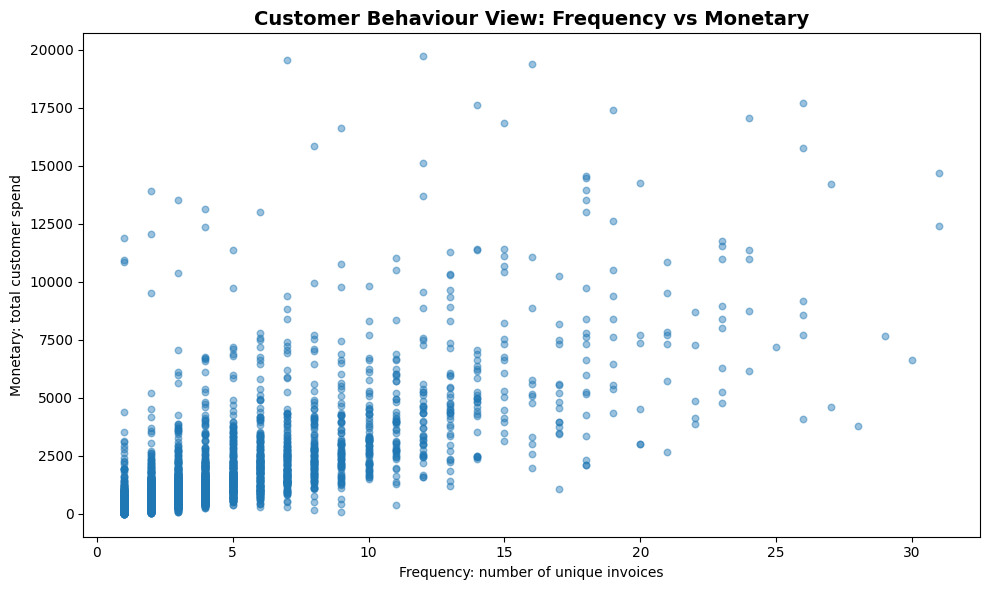

In [21]:
# Chart 6: Frequency vs Monetary scatter.
# Purpose:
# Create an Online Retail customer segmentation view.
# This replaces the Mall Customers income/spending scatter from the basic assignment.

scatter_data = rfm[
    (rfm["Frequency"] <= frequency_cap) &
    (rfm["Monetary"] <= monetary_cap)
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_data["Frequency"], scatter_data["Monetary"], alpha=0.45, s=22)
plt.title("Customer Behaviour View: Frequency vs Monetary", fontsize=14, weight="bold")
plt.xlabel("Frequency: number of unique invoices")
plt.ylabel("Monetary: total customer spend")
plt.tight_layout()
plt.show()

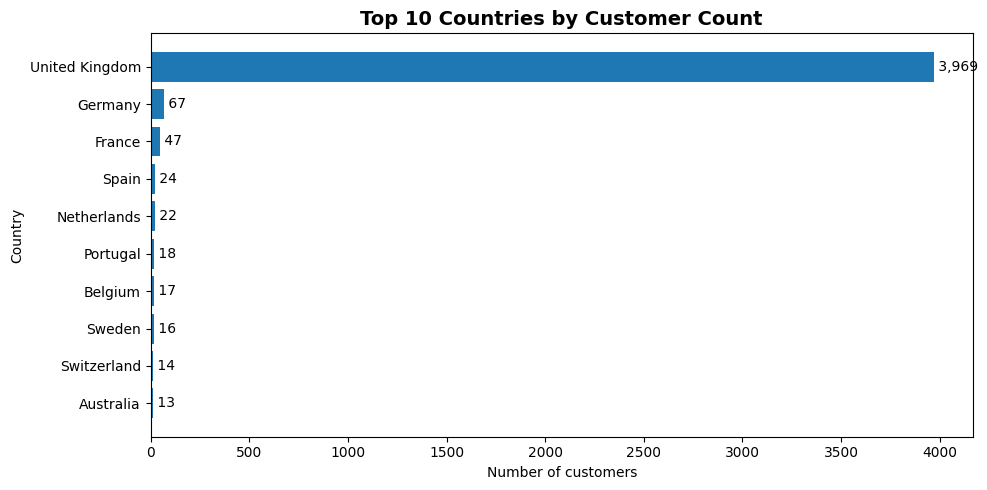

In [22]:
# Chart 7: Top customer countries.
# Purpose:
# Show the main country groups for later categorical clustering.

top_countries = (
    rfm["Country"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ["Country", "Customers"]

plt.figure(figsize=(10, 5))
bars = plt.barh(top_countries["Country"], top_countries["Customers"])
plt.title("Top 10 Countries by Customer Count", fontsize=14, weight="bold")
plt.xlabel("Number of customers")
plt.ylabel("Country")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f" {int(width):,}", va="center")

plt.tight_layout()
plt.show()

# 13. Outlier review

Customer data often contains extreme values.

Examples:

- very high spend customers,
- very frequent buyers,
- very inactive customers.

These values are not automatically wrong.  
They may represent important business customers.

So we review them now and handle them more carefully in later clustering notebooks.

In [23]:
# Outlier review using the 99th percentile.
# This does not remove customers.
# It simply tells us how many extreme customers exist.

outlier_summary = pd.DataFrame({
    "Feature": ["Recency", "Frequency", "Monetary"],
    "99th Percentile": [
        rfm["Recency"].quantile(0.99),
        rfm["Frequency"].quantile(0.99),
        rfm["Monetary"].quantile(0.99),
    ],
    "Customers Above 99th Percentile": [
        (rfm["Recency"] > rfm["Recency"].quantile(0.99)).sum(),
        (rfm["Frequency"] > rfm["Frequency"].quantile(0.99)).sum(),
        (rfm["Monetary"] > rfm["Monetary"].quantile(0.99)).sum(),
    ]
})

outlier_summary

,Feature,99th Percentile,Customers Above 99th Percentile
0,Recency,368.0000,38
1,Frequency,31.0000,43
2,Monetary,20004.3906,44


# 13.1 Outlier detection with multiple methods

The first outlier review used only the 99th percentile.

That is useful, but not enough.

Here we use several additional methods because different methods catch different types of unusual customers.

| Method | What it checks | Why it is useful |
|---|---|---|
| IQR rule | Values far outside the middle 50% | Simple statistical rule |
| Modified Z-score | Distance from median | More robust than normal Z-score |
| Isolation Forest | Customers that are easy to isolate | Good for unusual multi-feature patterns |
| Local Outlier Factor | Customers different from local neighbours | Good for local anomaly behaviour |

Important: we still do **not** remove these customers in Notebook 1.

We only flag them.

Later clustering notebooks can decide whether to:

- keep all customers,
- compare with outlier-aware methods,
- or study outlier customers separately.

In [ ]:
# Prepare RFM features for outlier detection.
# We use Recency, Frequency and Monetary because they describe customer behaviour.

outlier_feature_names = ["Recency", "Frequency", "Monetary"]

# outlier_data_raw keeps the original RFM values for readable reporting.

outlier_data_raw = rfm[outlier_feature_names].copy()

# RFM data is heavily skewed, especially Monetary and Frequency.
# log1p reduces skew while keeping zero-safe behaviour.
# log1p(x) means log(1 + x).

outlier_data_log = np.log1p(outlier_data_raw)

outlier_data_log.head()

,Recency,Frequency,Monetary
0,5.111988,2.484907,5.923881
1,1.386294,1.098612,7.188654
2,4.317488,0.693147,5.407889
3,3.784190,1.386294,7.890635
4,2.484907,0.693147,5.710195


In [25]:
# Method 1: IQR outlier rule.
# IQR = Q3 - Q1.
# A value is flagged if it is below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

Q1 = outlier_data_raw.quantile(0.25)
Q3 = outlier_data_raw.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# iqr_flags is True when a customer is outside the IQR range for any RFM feature.
iqr_flags = ((outlier_data_raw < lower_limit) | (outlier_data_raw > upper_limit)).any(axis=1)

print("Customers flagged by IQR rule:", f"{iqr_flags.sum():,}")

Customers flagged by IQR rule: 656


In [26]:
# Method 2: Modified Z-score on log-transformed RFM values.
# This is more robust than a normal Z-score because it uses the median.


def modified_z_score(series):
    """Calculate modified Z-score for one numeric pandas Series."""
    median_value = np.median(series)
    mad_value = np.median(np.abs(series - median_value))

    # If MAD is zero, all values are very similar.
    # Return zeros so nothing is incorrectly flagged.
    if mad_value == 0:
        return np.zeros(len(series))

    return 0.6745 * (series - median_value) / mad_value


modified_z_scores = outlier_data_log.apply(modified_z_score, axis=0)

# Common threshold: absolute modified Z-score greater than 3.5.
modified_z_flags = (np.abs(modified_z_scores) > 3.5).any(axis=1)

print("Customers flagged by modified Z-score:", f"{modified_z_flags.sum():,}")

Customers flagged by modified Z-score: 72


In [27]:
# Method 3 and 4: Isolation Forest and Local Outlier Factor.
# These methods look at multiple RFM features together.

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Scale the log-transformed RFM values for model-based outlier detection.
outlier_scaler = StandardScaler()
outlier_data_scaled = outlier_scaler.fit_transform(outlier_data_log)

# Isolation Forest:
# contamination=0.03 means we ask the model to flag around 3% of customers as unusual.
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

isolation_labels = isolation_model.fit_predict(outlier_data_scaled)
isolation_flags = isolation_labels == -1

# Local Outlier Factor:
# It compares each customer with nearby customers.
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03
)

lof_labels = lof_model.fit_predict(outlier_data_scaled)
lof_flags = lof_labels == -1

print("Customers flagged by Isolation Forest:", f"{isolation_flags.sum():,}")
print("Customers flagged by Local Outlier Factor:", f"{lof_flags.sum():,}")

Customers flagged by Isolation Forest: 130
Customers flagged by Local Outlier Factor: 130


In [28]:
# Combine all outlier flags into one review table.
# This table will be saved and used later if we want outlier-aware clustering.

rfm_outlier_review = rfm[[
    "CustomerID", "Recency", "Frequency", "Monetary", "Country"
]].copy()

# Store each method's decision.
rfm_outlier_review["Outlier_IQR"] = iqr_flags.values
rfm_outlier_review["Outlier_ModifiedZ"] = modified_z_flags.values
rfm_outlier_review["Outlier_IsolationForest"] = isolation_flags
rfm_outlier_review["Outlier_LOF"] = lof_flags

# Count how many methods flagged the customer.
flag_columns = [
    "Outlier_IQR",
    "Outlier_ModifiedZ",
    "Outlier_IsolationForest",
    "Outlier_LOF"
]

rfm_outlier_review["Outlier_Method_Count"] = rfm_outlier_review[flag_columns].sum(axis=1)

# Strong_Outlier means at least two methods agree.
rfm_outlier_review["Strong_Outlier"] = rfm_outlier_review["Outlier_Method_Count"] >= 2

outlier_method_summary = pd.DataFrame({
    "Method": ["IQR", "Modified Z-score", "Isolation Forest", "Local Outlier Factor", "Strong outlier: 2+ methods"],
    "Customers Flagged": [
        int(rfm_outlier_review["Outlier_IQR"].sum()),
        int(rfm_outlier_review["Outlier_ModifiedZ"].sum()),
        int(rfm_outlier_review["Outlier_IsolationForest"].sum()),
        int(rfm_outlier_review["Outlier_LOF"].sum()),
        int(rfm_outlier_review["Strong_Outlier"].sum()),
    ]
})

outlier_method_summary

,Method,Customers Flagged
0,IQR,656
1,Modified Z-score,72
2,Isolation Forest,130
3,Local Outlier Factor,130
4,Strong outlier: 2+ methods,161


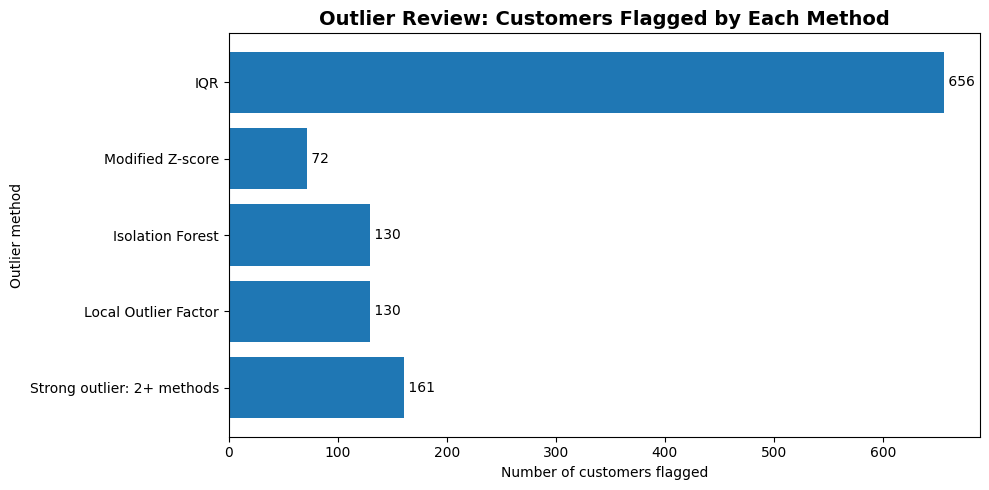

In [29]:
# Chart 9: Outlier counts by method.
# Purpose:
# Compare how strict or broad each outlier method is.

plt.figure(figsize=(10, 5))
bars = plt.barh(outlier_method_summary["Method"], outlier_method_summary["Customers Flagged"])
plt.title("Outlier Review: Customers Flagged by Each Method", fontsize=14, weight="bold")
plt.xlabel("Number of customers flagged")
plt.ylabel("Outlier method")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f" {int(width):,}", va="center")

plt.tight_layout()
plt.show()

# 13.2 Imbalance check

In classification, imbalance usually means one target class is much larger than another.

In clustering, we do **not** have a target label.

So we do not use SMOTE or class balancing here.

However, imbalance can still appear in project features.

Examples:

- one country may dominate the dataset,
- one RFM category may be much larger than another,
- rare countries or rare customer types may be hidden.

So we check group sizes now.

This helps later notebooks decide whether sampling, grouping, or careful interpretation is needed.

In [30]:
# Check group balance for categorical customer features.
# This is useful for K-Modes and K-Prototypes later.

balance_features = ["Country", "RecencyGroup", "FrequencyGroup", "MonetaryGroup"]

balance_rows = []

for feature in balance_features:
    counts = customer_categorical_features[feature].value_counts(dropna=False)
    largest_group = counts.index[0]
    largest_count = counts.iloc[0]
    largest_share = largest_count / len(customer_categorical_features) * 100

    balance_rows.append({
        "Feature": feature,
        "Largest Group": str(largest_group),
        "Largest Group Customers": int(largest_count),
        "Largest Group Share %": round(largest_share, 2),
        "Number of Groups": int(counts.shape[0])
    })

customer_group_balance_check = pd.DataFrame(balance_rows)
customer_group_balance_check

,Feature,Largest Group,Largest Group Customers,Largest Group Share %,Number of Groups
0,Country,United Kingdom,3969,92.05,37
1,RecencyGroup,Inactive,1438,33.35,3
2,FrequencyGroup,High Frequency,1438,33.35,3
3,MonetaryGroup,High Monetary,1438,33.35,3


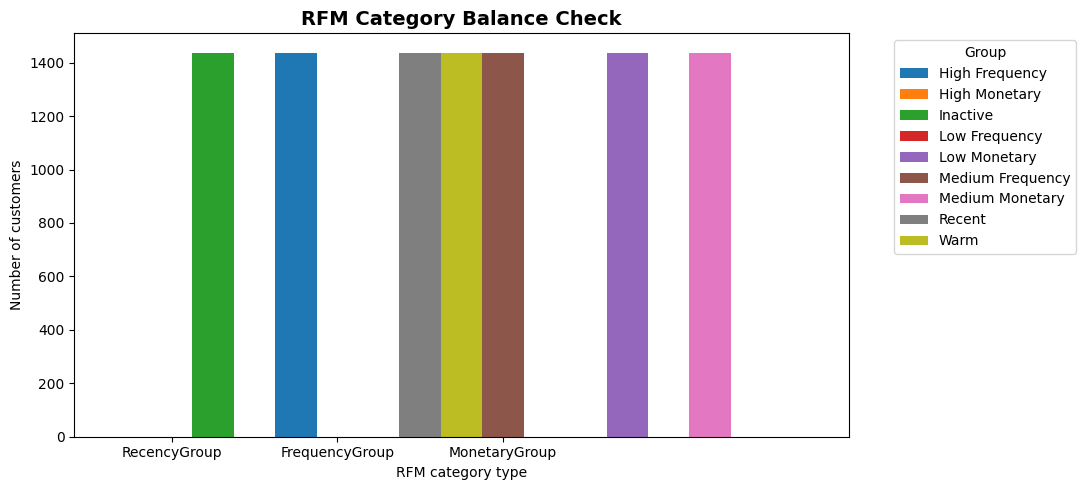

In [31]:
# Chart 10: RFM category balance.
# Purpose:
# Confirm that Recency, Frequency and Monetary groups are reasonably balanced.

rfm_group_counts = []

for feature in ["RecencyGroup", "FrequencyGroup", "MonetaryGroup"]:
    counts = customer_categorical_features[feature].value_counts().reset_index()
    counts.columns = ["Group", "Customers"]
    counts["Feature"] = feature
    rfm_group_counts.append(counts)

rfm_group_counts = pd.concat(rfm_group_counts, ignore_index=True)

plt.figure(figsize=(11, 5))

# Create a simple grouped bar chart manually with matplotlib.
features = ["RecencyGroup", "FrequencyGroup", "MonetaryGroup"]
x_positions = np.arange(len(features))
bar_width = 0.25

for idx, group_name in enumerate(sorted(rfm_group_counts["Group"].astype(str).unique())):
    group_values = []
    for feature in features:
        match = rfm_group_counts[
            (rfm_group_counts["Feature"] == feature) &
            (rfm_group_counts["Group"].astype(str) == group_name)
        ]
        group_values.append(int(match["Customers"].iloc[0]) if len(match) > 0 else 0)

    plt.bar(x_positions + idx * bar_width, group_values, width=bar_width, label=group_name)

plt.title("RFM Category Balance Check", fontsize=14, weight="bold")
plt.xlabel("RFM category type")
plt.ylabel("Number of customers")
plt.xticks(x_positions + bar_width, features)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
# Decide whether imbalance techniques are required now.
# For this unsupervised clustering setup, we do not apply SMOTE or class resampling.
# Instead, we record the decision clearly.

resampling_decision = pd.DataFrame([
    {
        "Question": "Do we have a supervised target class?",
        "Answer": "No",
        "Decision": "Do not apply SMOTE or supervised class-balancing techniques."
    },
    {
        "Question": "Can feature groups be imbalanced?",
        "Answer": "Yes",
        "Decision": "Review group sizes and interpret small/large groups carefully."
    },
    {
        "Question": "What do we do later if one group dominates?",
        "Answer": "Use sampling for demos or group rare categories when needed.",
        "Decision": "Handle inside the relevant method notebook, not here."
    }
])

resampling_decision

,Question,Answer,Decision
0,Do we have a supervised target class?,No,Do not apply SMOTE or supervised class-balanci...
1,Can feature groups be imbalanced?,Yes,Review group sizes and interpret small/large g...
2,What do we do later if one group dominates?,Use sampling for demos or group rare categorie...,"Handle inside the relevant method notebook, no..."


# 14. Scaling RFM features

Most clustering methods use distance.

If features have very different scales, the largest feature can dominate the result.

Example:

| Feature | Typical range |
|---|---:|
| Recency | 1 to 400 |
| Frequency | 1 to 200 |
| Monetary | 1 to 100,000 |

Without scaling, Monetary can dominate the clustering.

We use `StandardScaler` so Recency, Frequency, and Monetary are placed on comparable scales.

In [33]:
# Scale RFM features using StandardScaler.
# rfm_scaled will be used by distance-based clustering methods in later notebooks.

from sklearn.preprocessing import StandardScaler

rfm_features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled_values = scaler.fit_transform(rfm[rfm_features])

rfm_scaled = pd.DataFrame(
    rfm_scaled_values,
    columns=[f"{feature}_Scaled" for feature in rfm_features]
)

# Keep CustomerID so we can join scaled values back to customer profiles later.
rfm_scaled.insert(0, "CustomerID", rfm["CustomerID"].values)

print("Scaled RFM shape:", rfm_scaled.shape)

rfm_scaled.head()

Scaled RFM shape: (4312, 4)


,CustomerID,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,12346,0.762299,0.801087,-0.187139
1,12347,-0.910402,-0.300603,-0.080475
2,12348,-0.177305,-0.423013,-0.204052
3,12349,-0.497389,-0.178193,0.070784
4,12351,-0.827799,-0.423013,-0.195212


In [34]:
# Scaled feature summary.
# Mean should be close to 0.
# Standard deviation should be close to 1.

scaled_summary = (
    rfm_scaled.drop(columns=["CustomerID"])
    .agg(["mean", "std", "min", "max"])
    .T
    .round(3)
)

scaled_summary

,mean,std,min,max
Recency_Scaled,0.0,1.0,-0.931,2.920
Frequency_Scaled,0.0,1.0,-0.423,24.549
Monetary_Scaled,-0.0,1.0,-0.229,38.956


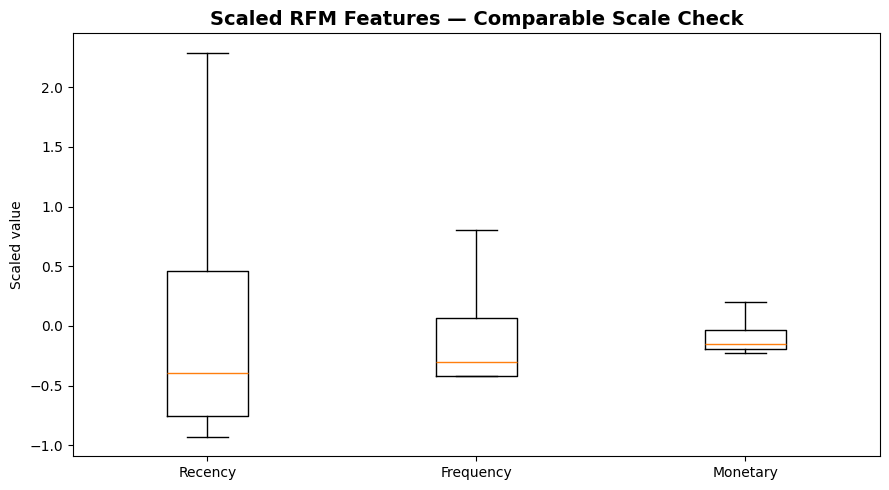

In [35]:
# Chart 8: Scaled RFM boxplot without extreme fliers.
# Purpose:
# Confirm that Recency, Frequency and Monetary are now on comparable scales.

plt.figure(figsize=(9, 5))
plt.boxplot(
    [
        rfm_scaled["Recency_Scaled"],
        rfm_scaled["Frequency_Scaled"],
        rfm_scaled["Monetary_Scaled"]
    ],
    labels=["Recency", "Frequency", "Monetary"],
    showfliers=False
)
plt.title("Scaled RFM Features — Comparable Scale Check", fontsize=14, weight="bold")
plt.ylabel("Scaled value")
plt.tight_layout()
plt.show()

# 17. Save prepared data

The next notebooks will load these files.

This keeps the project modular.

Notebook 2 will start from these outputs and apply:

- K-Means,
- MiniBatchKMeans,
- K-Modes,
- K-Medoids,
- K-Prototypes.

In [36]:
# Save prepared files for the next notebooks.
# These files allow later notebooks to start directly from clean customer data.

# Clean transaction-level data.
clean_data.to_csv(OUTPUT_DIR / "online_retail_clean.csv", index=False)

# Main customer-level numerical table.
rfm.to_csv(OUTPUT_DIR / "rfm_customer_table.csv", index=False)

# Scaled RFM table for distance-based clustering.
rfm_scaled.to_csv(OUTPUT_DIR / "rfm_scaled.csv", index=False)

# Categorical customer table for K-Modes and K-Prototypes.
customer_categorical_features.to_csv(OUTPUT_DIR / "customer_categorical_features.csv", index=False)

# Outlier review table for outlier-aware clustering decisions.
rfm_outlier_review.to_csv(OUTPUT_DIR / "rfm_outlier_review.csv", index=False)

# Group balance / imbalance review tables.
customer_group_balance_check.to_csv(OUTPUT_DIR / "customer_group_balance_check.csv", index=False)
resampling_decision.to_csv(OUTPUT_DIR / "resampling_decision.csv", index=False)

print("Saved files:")
print("- outputs/online_retail_clean.csv")
print("- outputs/rfm_customer_table.csv")
print("- outputs/rfm_scaled.csv")
print("- outputs/customer_categorical_features.csv")
print("- outputs/rfm_outlier_review.csv")
print("- outputs/customer_group_balance_check.csv")
print("- outputs/resampling_decision.csv")
print("- outputs/rfm_feature_summary.csv")
print("- outputs/project_method_checklist.csv")

Saved files:
- outputs/online_retail_clean.csv
- outputs/rfm_customer_table.csv
- outputs/rfm_scaled.csv
- outputs/customer_categorical_features.csv
- outputs/rfm_outlier_review.csv
- outputs/customer_group_balance_check.csv
- outputs/resampling_decision.csv
- outputs/rfm_feature_summary.csv
- outputs/project_method_checklist.csv


# 18. Dynamic conclusion

Run the next cell after the notebook finishes.

It creates a conclusion using your actual output numbers.

This keeps the conclusion specific if the dataset version changes later.

In [37]:
# Dynamic conclusion with actual numbers.
# This cell prints a professional conclusion based on the notebook output.
# It is useful if the dataset version changes in the future.

from IPython.display import Markdown, display

customers_count = rfm.shape[0]
clean_rows = clean_data.shape[0]
removed_rows = initial_rows - clean_rows
removed_pct = removed_rows / initial_rows * 100

avg_recency = rfm["Recency"].mean()
median_frequency = rfm["Frequency"].median()
total_revenue = rfm["Monetary"].sum()
median_monetary = rfm["Monetary"].median()

top_country = rfm["Country"].value_counts().idxmax()
top_country_customers = rfm["Country"].value_counts().max()
top_country_share = top_country_customers / customers_count * 100

strong_outlier_count = int(rfm_outlier_review["Strong_Outlier"].sum())
strong_outlier_share = strong_outlier_count / customers_count * 100

largest_group_row = customer_group_balance_check.sort_values(
    "Largest Group Share %", ascending=False
).iloc[0]

conclusion = f"""
## Notebook 1 Dynamic Conclusion

The Online Retail data was cleaned and converted into a customer-level RFM table.

### Key results

| Result | Value |
|---|---:|
| Loaded dataset file | {loaded_file_name} |
| Raw transaction rows | {initial_rows:,.0f} |
| Clean purchase rows | {clean_rows:,.0f} |
| Rows removed during cleaning | {removed_rows:,.0f} ({removed_pct:.1f}%) |
| Customers in final RFM table | {customers_count:,.0f} |
| Total customer revenue | {total_revenue:,.2f} |
| Average Recency | {avg_recency:.1f} days |
| Median Frequency | {median_frequency:.1f} invoices |
| Median Monetary | {median_monetary:,.2f} |
| Largest customer country | {top_country} ({top_country_share:.1f}% of customers) |
| Strong outliers flagged by 2+ methods | {strong_outlier_count:,.0f} ({strong_outlier_share:.1f}% of customers) |
| Most imbalanced reviewed feature | {largest_group_row['Feature']} → {largest_group_row['Largest Group']} ({largest_group_row['Largest Group Share %']:.1f}%) |

### Actionable conclusion

The project now has one clean row per customer.  
This is the correct structure for clustering.

The data is ready for:

- numerical clustering with K-Means, K-Medoids, DBSCAN, OPTICS, BIRCH, Hierarchical Clustering, and GMM,
- categorical clustering with K-Modes,
- mixed-data clustering with K-Prototypes,
- outlier-aware comparisons,
- grid-based and constraint-based demos,
- and final customer persona analysis.

### Important modelling decision

No SMOTE or supervised imbalance technique is applied in this notebook because clustering has no target label.  
Instead, group-size imbalance is reviewed and saved for later method-specific interpretation.

### Files created for the next notebooks

- `outputs/online_retail_clean.csv`
- `outputs/rfm_customer_table.csv`
- `outputs/rfm_scaled.csv`
- `outputs/customer_categorical_features.csv`
- `outputs/rfm_outlier_review.csv`
- `outputs/customer_group_balance_check.csv`
- `outputs/resampling_decision.csv`
- `outputs/rfm_feature_summary.csv`
- `outputs/project_method_checklist.csv`
"""

display(Markdown(conclusion))


## Notebook 1 Dynamic Conclusion

The Online Retail data was cleaned and converted into a customer-level RFM table.

### Key results

| Result | Value |
|---|---:|
| Loaded dataset file | online_retail_II.xlsx |
| Raw transaction rows | 525,461 |
| Clean purchase rows | 400,916 |
| Rows removed during cleaning | 124,545 (23.7%) |
| Customers in final RFM table | 4,312 |
| Total customer revenue | 8,798,233.73 |
| Average Recency | 91.2 days |
| Median Frequency | 2.0 invoices |
| Median Monetary | 701.62 |
| Largest customer country | United Kingdom (92.0% of customers) |
| Strong outliers flagged by 2+ methods | 161 (3.7% of customers) |
| Most imbalanced reviewed feature | Country → United Kingdom (92.0%) |

### Actionable conclusion

The project now has one clean row per customer.  
This is the correct structure for clustering.

The data is ready for:

- numerical clustering with K-Means, K-Medoids, DBSCAN, OPTICS, BIRCH, Hierarchical Clustering, and GMM,
- categorical clustering with K-Modes,
- mixed-data clustering with K-Prototypes,
- outlier-aware comparisons,
- grid-based and constraint-based demos,
- and final customer persona analysis.

### Important modelling decision

No SMOTE or supervised imbalance technique is applied in this notebook because clustering has no target label.  
Instead, group-size imbalance is reviewed and saved for later method-specific interpretation.

### Files created for the next notebooks

- `outputs/online_retail_clean.csv`
- `outputs/rfm_customer_table.csv`
- `outputs/rfm_scaled.csv`
- `outputs/customer_categorical_features.csv`
- `outputs/rfm_outlier_review.csv`
- `outputs/customer_group_balance_check.csv`
- `outputs/resampling_decision.csv`
- `outputs/rfm_feature_summary.csv`
- `outputs/project_method_checklist.csv`


# 19. Final conclusion from the completed run

The notebook was tested with the KaggleHub file **`online_retail_II.xlsx`**.

### Final numbers from the completed run

| Result | Value |
|---|---:|
| Raw transaction rows | 525,461 |
| Clean purchase rows | 400,916 |
| Rows removed during cleaning | 124,545 |
| Customers in final RFM table | 4,312 |
| Average Recency | 91.17 days |
| Median Frequency | 2 invoices |
| Median Monetary | 701.62 |
| Mean Monetary | 2,040.41 |
| 99th percentile Recency | 368 days |
| 99th percentile Frequency | 31 invoices |
| 99th percentile Monetary | 20,004.39 |
| Customers above 99th percentile Recency | 38 |
| Customers above 99th percentile Frequency | 43 |
| Customers above 99th percentile Monetary | 44 |

### What this means

The raw transaction data was successfully converted into a clean customer-level table.

The final RFM table contains **4,312 customers**.  
This is the correct format for clustering because each row now represents one customer.

The data is strongly skewed.  
Most customers have low-to-medium spend, while a small number of customers spend much more than the rest.

That is why this notebook includes several outlier checks instead of relying on only one method.

### Actionable conclusion

Notebook 1 is complete when all output files are created.

The next notebook can safely use the prepared files for partitioning methods:

- K-Means,
- MiniBatchKMeans,
- K-Modes,
- K-Medoids,
- and K-Prototypes.

# 20. Notebook 1 completion checklist

| Requirement | Status |
|---|---|
| Project files and learning roadmap included | Complete |
| Full method list included | Complete |
| Online Retail loaded with KaggleHub | Complete after run |
| Column-name differences handled | Complete |
| Cleaning logic explained and implemented | Complete |
| RFM table created | Complete after run |
| Categorical customer table created | Complete after run |
| EDA charts included | Complete |
| Multiple outlier methods included | Complete |
| Imbalance / group-size check included | Complete |
| Scaling with StandardScaler included | Complete |
| Outputs saved for next notebooks | Complete after run |
| Final Markdown conclusion included | Complete |

Notebook 1 is complete when all cells run without error and the output files are created.